### Interpretability - feature metrics

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [ ]:
coral_df = pd.read_csv("/work/hs325/World_Corals/Cleaned data CSVs/qc_data.csv")
met_df = pd.read_csv("/work/hs325/World_Corals/Cleaned data CSVs/merged_met_plot_df.csv")

coral_df['scleractinia'] = np.where(coral_df['host_order'] == 'Scleractinia', 1, 0)
met_df['refined_origin'] = met_df['refined_origin'].str.replace('Host', 'Coral')

X = coral_df[coral_df.columns.intersection(met_df['metabolite'])]
y = coral_df['scleractinia']
X = X.to_numpy()
y = y.to_numpy()
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123, stratify=y)

accuracy 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       1.00      1.00      1.00        86

    accuracy                           1.00       114
   macro avg       1.00      1.00      1.00       114
weighted avg       1.00      1.00      1.00       114



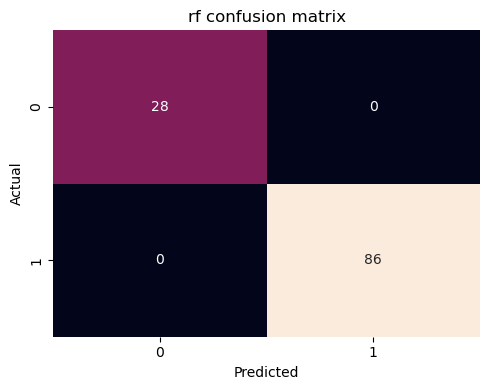

In [4]:
rf_path = "/work/hs325/World_Corals/machine_learning/hpt_impurity_importance/models/RF_best_model.joblib"
rf = joblib.load(rf_path)
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"accuracy {acc:.4f}")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True,cbar=False)
plt.title("rf confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [5]:
## get rf hyperparameters
params = rf.get_params()
params


{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 43,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 2,
 'min_samples_split': 10,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 1289,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 123,
 'verbose': 0,
 'warm_start': False}

accuracy 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       1.00      1.00      1.00        86

    accuracy                           1.00       114
   macro avg       1.00      1.00      1.00       114
weighted avg       1.00      1.00      1.00       114



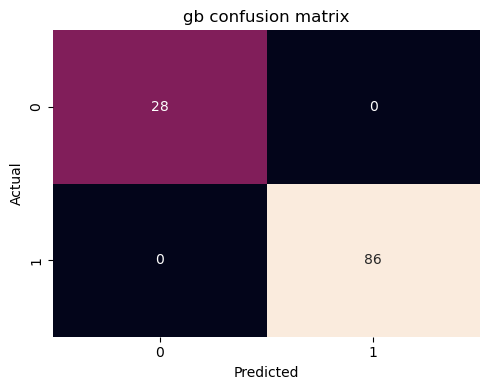

In [6]:
gb_path = "/work/hs325/World_Corals/machine_learning/hpt_impurity_importance/models/GB_best_model.joblib"
gb = joblib.load(gb_path)
y_pred = gb.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"accuracy {acc:.4f}")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True,cbar=False)
plt.title("gb confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [ ]:
# get gb hyperparameters
gb_params = gb.get_params(deep=True)
gb_params

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': 0.8447518569174499,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'logloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': 0.19641852194843049,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.08760576273693083,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 15,
 'max_leaves': None,
 'min_child_weight': 1,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 1640,
 'n_jobs': -1,
 'num_parallel_tree': None,
 'random_state': 123,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': 0.7311002144576508,
 'tree_method': 'hist',
 'validate_parameters': None,

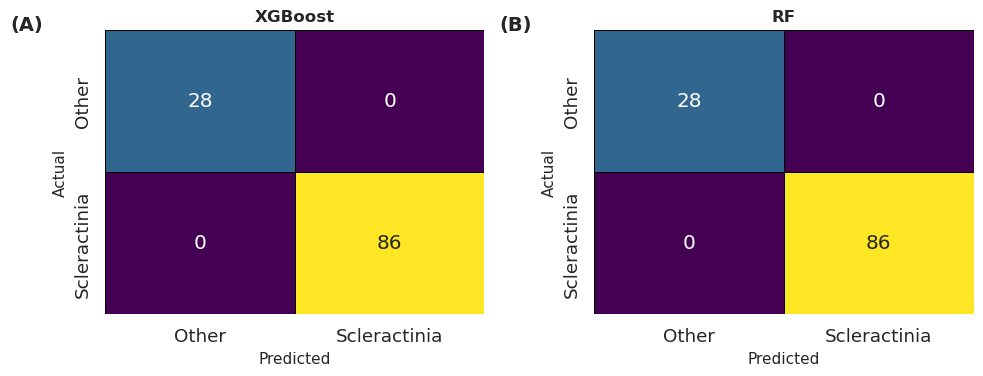

In [14]:
# Combine confusion matrices into multipanel figure for publication

import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

gb = joblib.load("/work/hs325/World_Corals/machine_learning/hpt_impurity_importance/models/GB_best_model.joblib")
rf = joblib.load("/work/hs325/World_Corals/machine_learning/hpt_impurity_importance/models/RF_best_model.joblib")

y_pred_gb = gb.predict(X_test)
y_pred_rf = rf.predict(X_test)

cm_gb = confusion_matrix(y_test, y_pred_gb)
cm_rf = confusion_matrix(y_test, y_pred_rf)

labels = ["Other", "Scleractinia"]
sns.set(style="white", font_scale=1.2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# -----------------------------
# GB plot (A)
# -----------------------------
sns.heatmap(
    cm_gb,
    annot=True,
    fmt="d",
    cmap="viridis",
    cbar=False,
    ax=axes[0],
    linewidths=0.5,
    linecolor='black',
    xticklabels=labels,
    yticklabels=labels
)

axes[0].set_title("XGBoost", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Predicted", fontsize=11)
axes[0].set_ylabel("Actual", fontsize=11)

# Panel label
axes[0].text(
    -0.25, 1.05, "(A)",
    transform=axes[0].transAxes,
    fontsize=14,
    fontweight="bold",
    va="top"
)

# -----------------------------
# RF plot (B)
# -----------------------------
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="viridis",
    cbar=False,
    ax=axes[1],
    linewidths=0.5,
    linecolor='black',
    xticklabels=labels,
    yticklabels=labels
)

axes[1].set_title("RF", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Predicted", fontsize=11)
axes[1].set_ylabel("Actual", fontsize=11)

axes[1].text(
    -0.25, 1.05, "(B)",
    transform=axes[1].transAxes,
    fontsize=14,
    fontweight="bold",
    va="top"
)

plt.tight_layout()

plt.savefig(
    "/work/hs325/World_Corals/misc/figs/confusion_matrix_combined.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
feature_names = coral_df.columns.intersection(met_df['metabolite'])

def get_feature_importances_df(gb_importances, rf_importances, feature_names):
    
    gb_df = pd.DataFrame({
        'Feature': feature_names,
        'XGBoost_Importance': gb_importances
    })

    rf_df = pd.DataFrame({
        'Feature': feature_names,
        'RandomForest_Importance': rf_importances
    })

    merged_df = pd.merge(gb_df, rf_df, on='Feature', how='outer')
    
    merged_df = merged_df.set_index('Feature')
    merged_df['Total_Importance'] = merged_df['XGBoost_Importance'] + merged_df['RandomForest_Importance']
    merged_df = merged_df.sort_values(by='Total_Importance', ascending=False)
    merged_df = merged_df.drop(columns=['Total_Importance'])
    return merged_df

def plot_top_features(importances, feature_names, title, top_n=50):
    indices = np.argsort(importances)[::-1][:top_n]
    top_features = np.array(feature_names)[indices]
    top_importances = importances[indices]

    plt.figure(figsize=(10, 6))
    plt.barh(range(len(top_features)), top_importances[::-1])
    plt.yticks(range(len(top_features)), top_features[::-1])
    plt.title(title)
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

feature_importance_comparison_df = get_feature_importances_df(
    gb.feature_importances_, 
    rf.feature_importances_, 
    feature_names
)

plot_top_features(gb.feature_importances_, feature_names, "Top 50 XGBoost Feature Importances", top_n=50)
plot_top_features(rf.feature_importances_, feature_names, "Top 50 Random Forest Feature Importances", top_n=50)

### Optionally save as csv

In [6]:
# feature_importance_comparison_df.to_csv("featureimportanceallmets.csv")